In [3]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


food reard list:  ['10', '634', '1258', '1881', '2505', '3129', '3752', '4376', '5000']


/opt/homebrew/anaconda3/envs/lab/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


ycstore/seed_0_varyrewardemulatev2_epoch_0


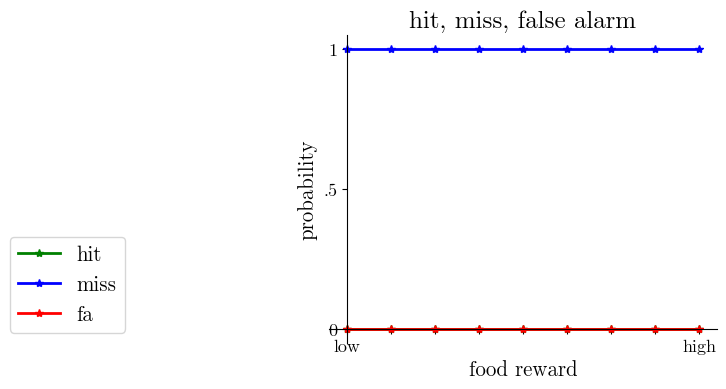

webf NOT subset; don't know how to subset; dropped


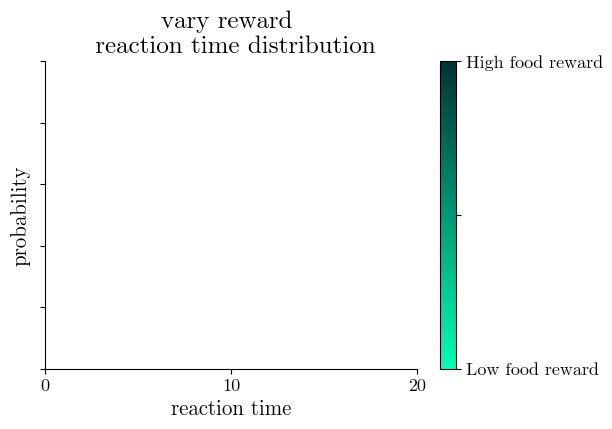

ycstore/seed_0_varyrewardemulatev2_epoch_1


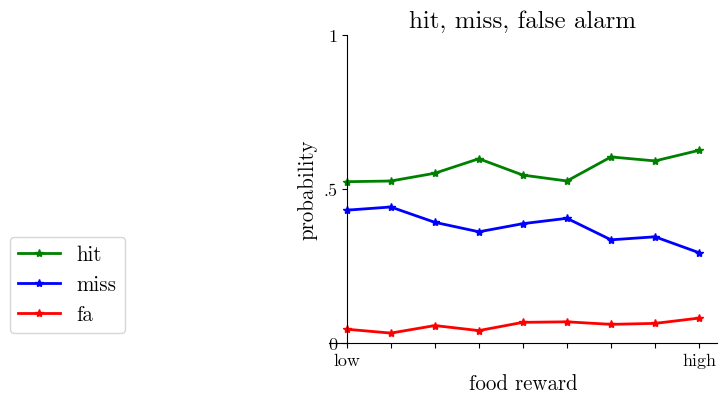

webf NOT subset; don't know how to subset; dropped


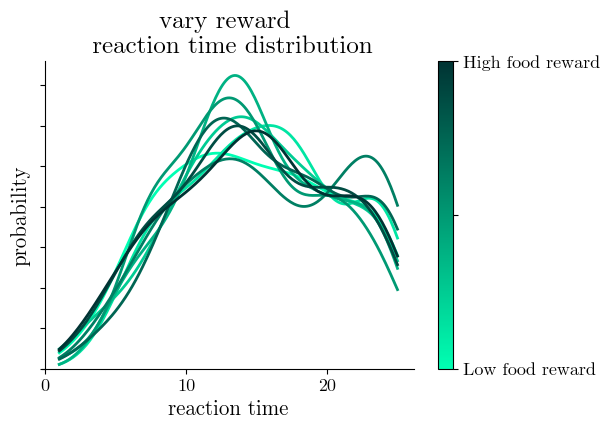

ycstore/seed_0_varyrewardemulatev2_epoch_2


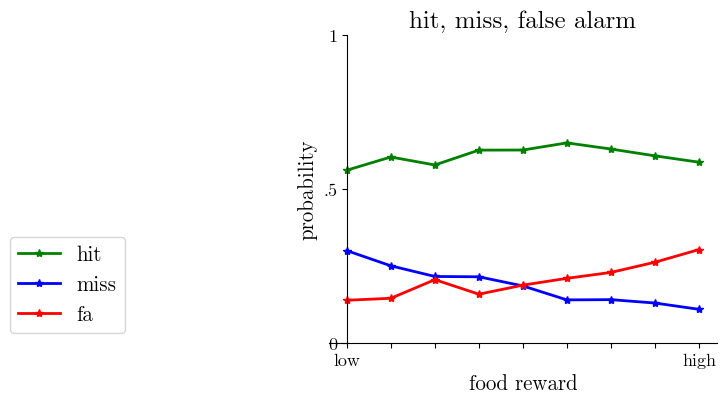

webf NOT subset; don't know how to subset; dropped


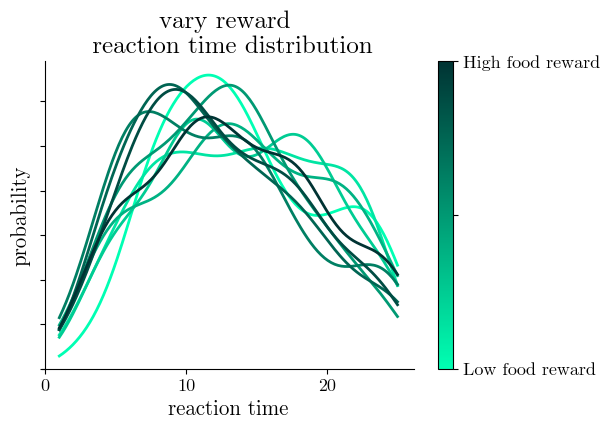

ycstore/seed_0_varyrewardemulatev2_epoch_3


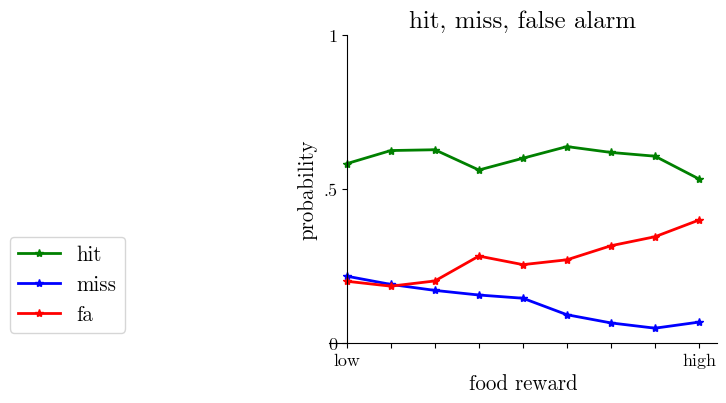

webf NOT subset; don't know how to subset; dropped


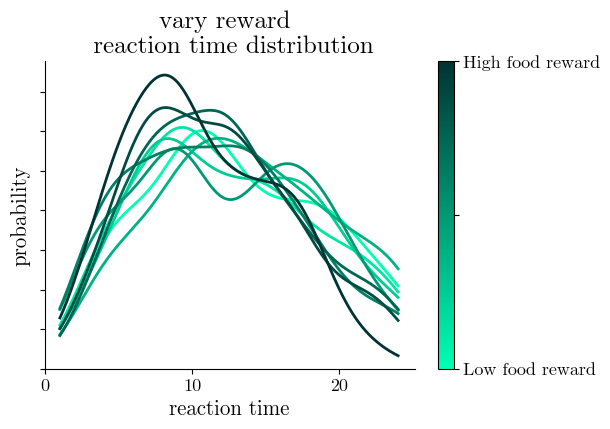

ycstore/seed_0_varyrewardemulatev2_epoch_4


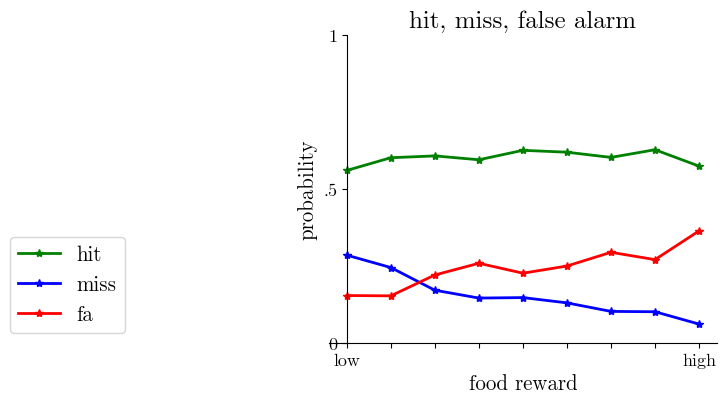

webf NOT subset; don't know how to subset; dropped


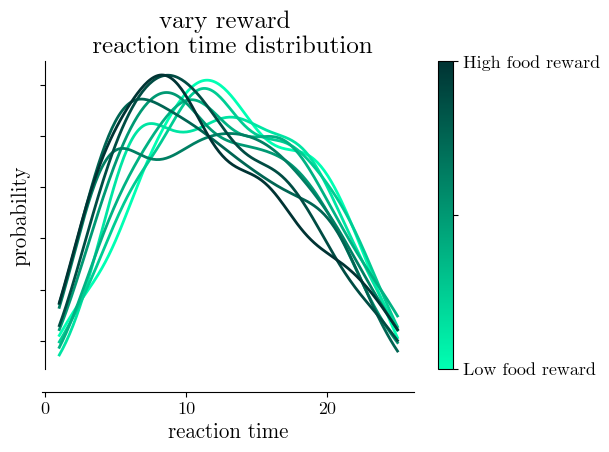

ycstore/seed_0_varyrewardemulatev2_epoch_5


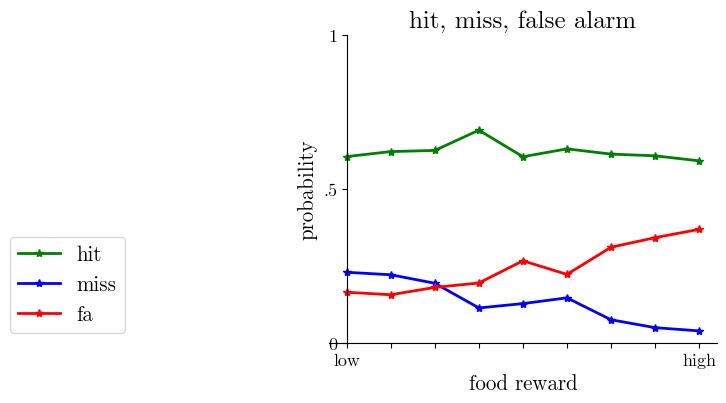

webf NOT subset; don't know how to subset; dropped


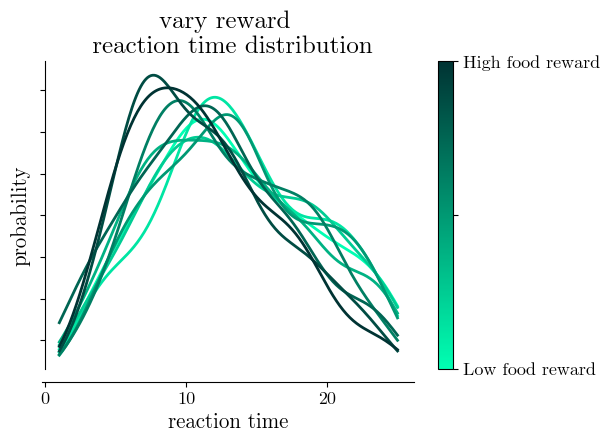

ycstore/seed_0_varyrewardemulatev2_epoch_6


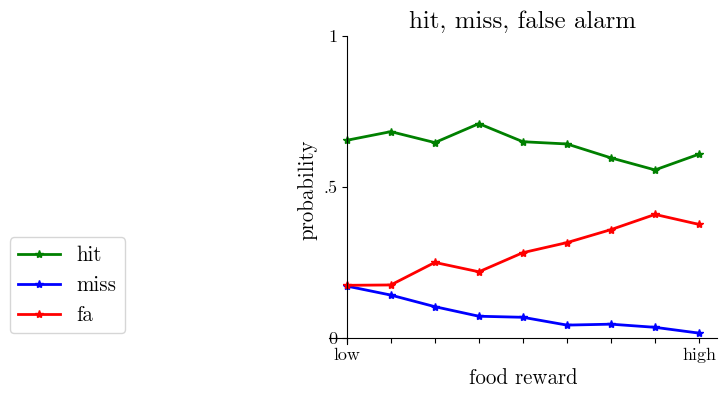

webf NOT subset; don't know how to subset; dropped


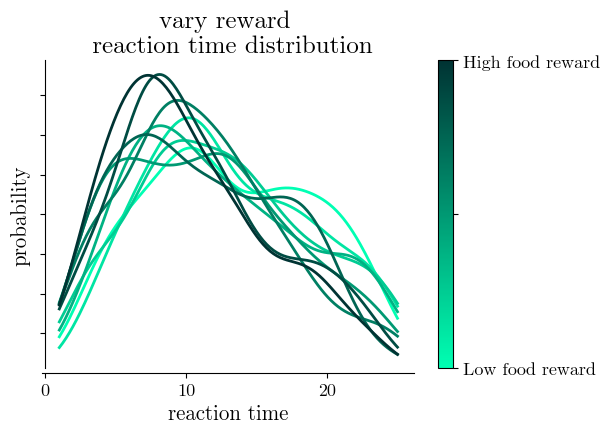

ycstore/seed_0_varyrewardemulatev2_epoch_7


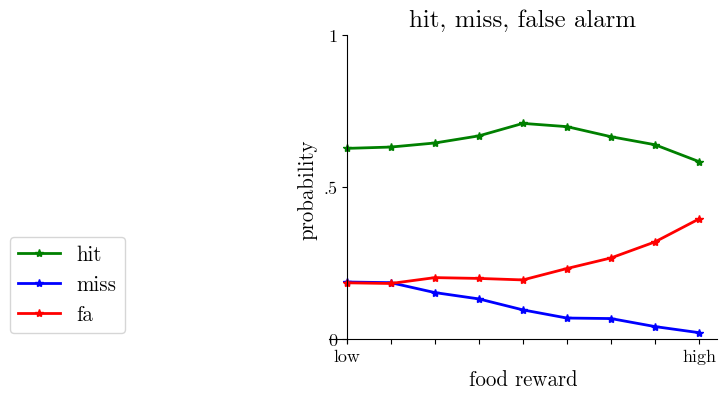

webf NOT subset; don't know how to subset; dropped


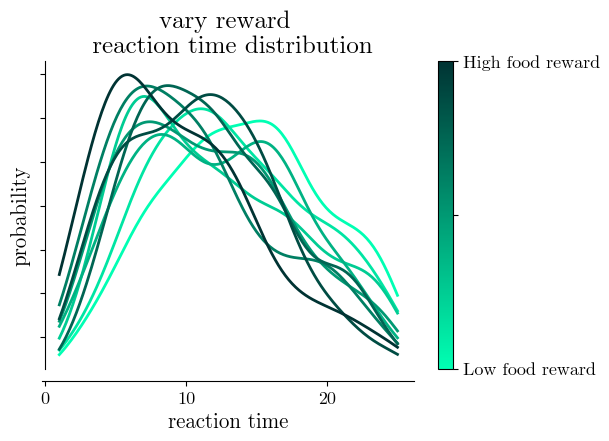

ycstore/seed_0_varyrewardemulatev2_epoch_8


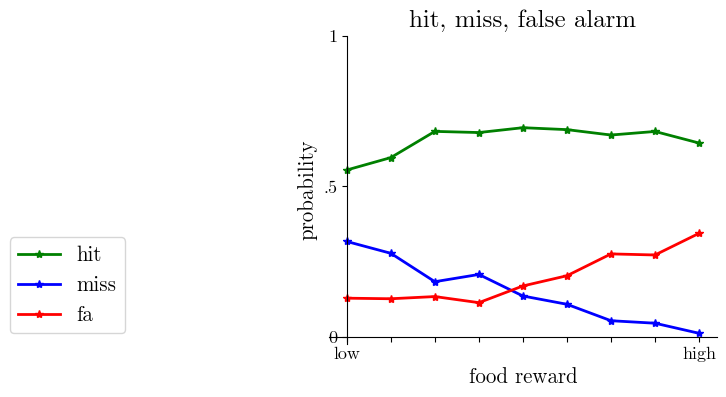

webf NOT subset; don't know how to subset; dropped


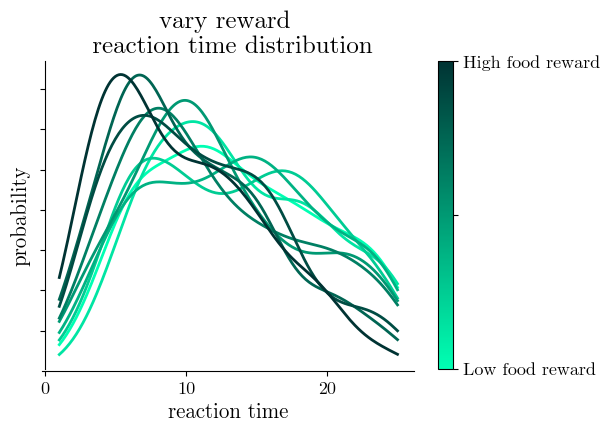

ycstore/seed_0_varyrewardemulatev2_epoch_9


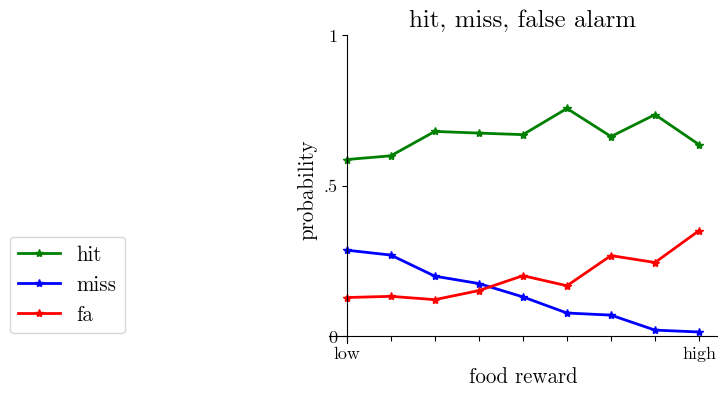

webf NOT subset; don't know how to subset; dropped


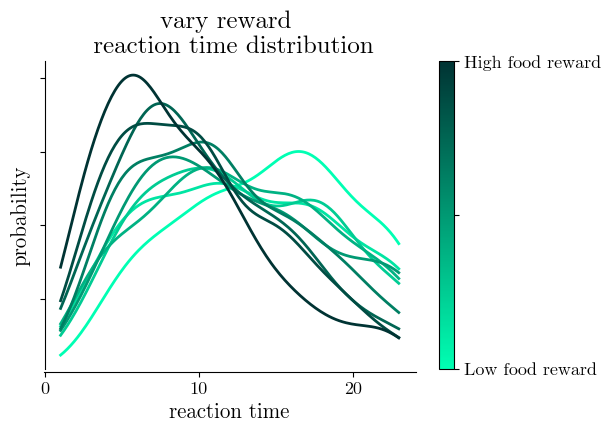

ycstore/seed_0_varyrewardemulatev2_epoch_10


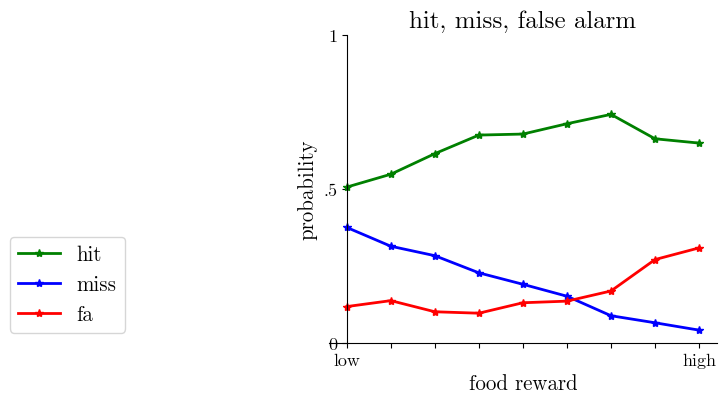

webf NOT subset; don't know how to subset; dropped


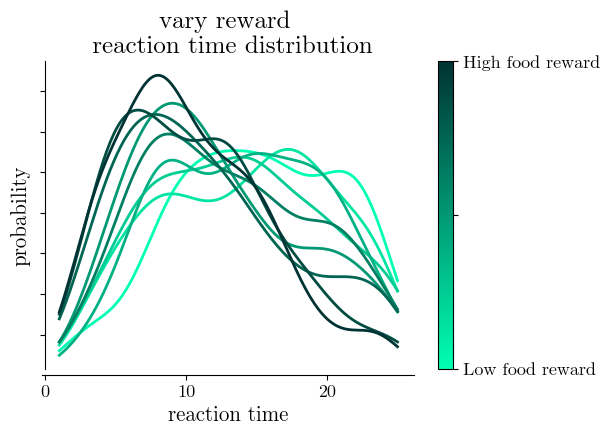

ycstore/seed_0_varyrewardemulatev2_epoch_11


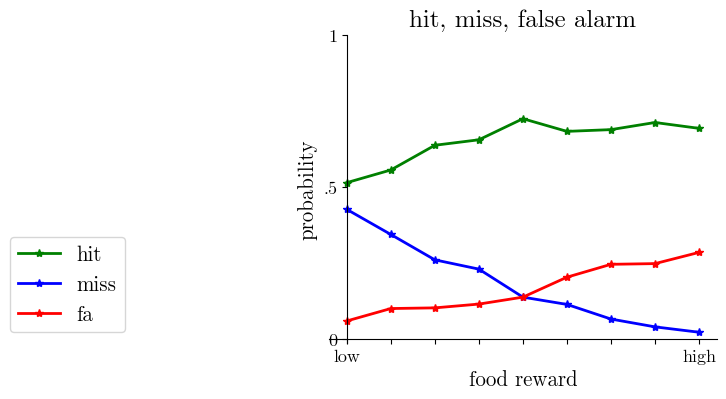

webf NOT subset; don't know how to subset; dropped


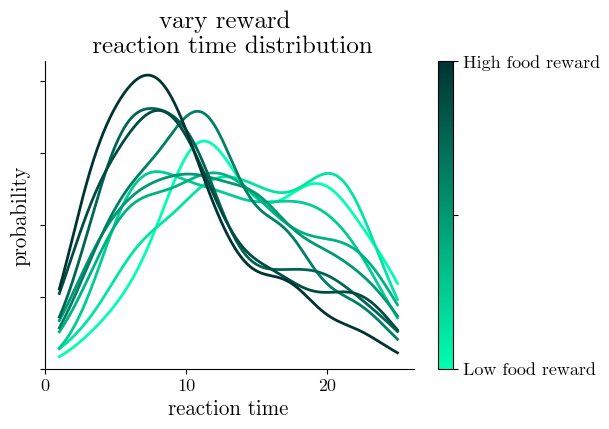

ycstore/seed_0_varyrewardemulatev2_epoch_12


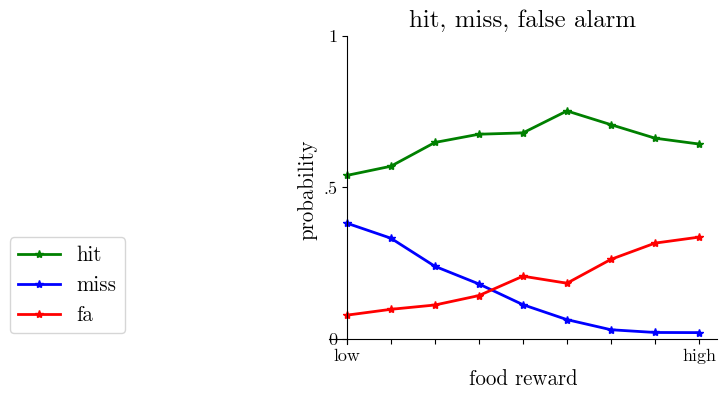

webf NOT subset; don't know how to subset; dropped


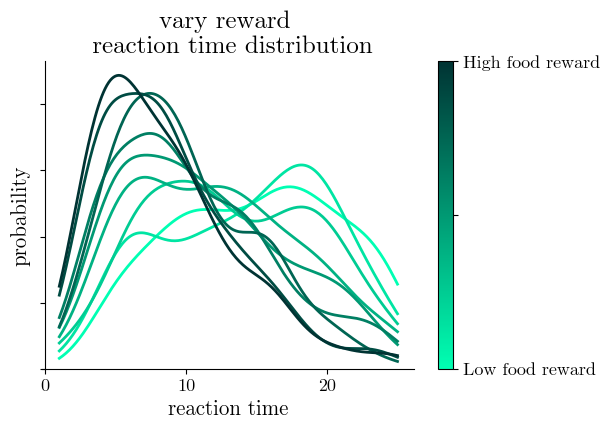

ycstore/seed_0_varyrewardemulatev2_epoch_13


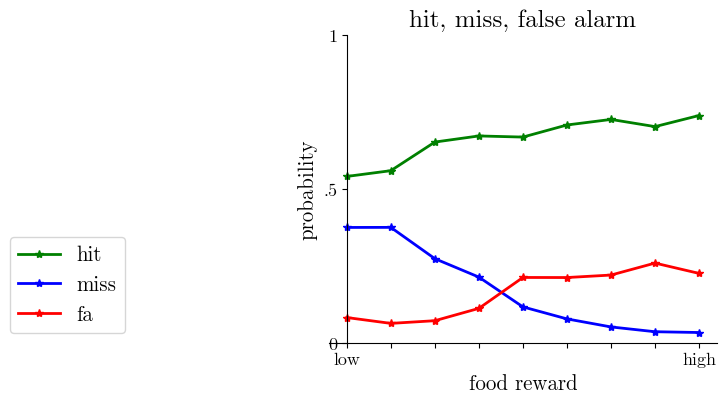

webf NOT subset; don't know how to subset; dropped


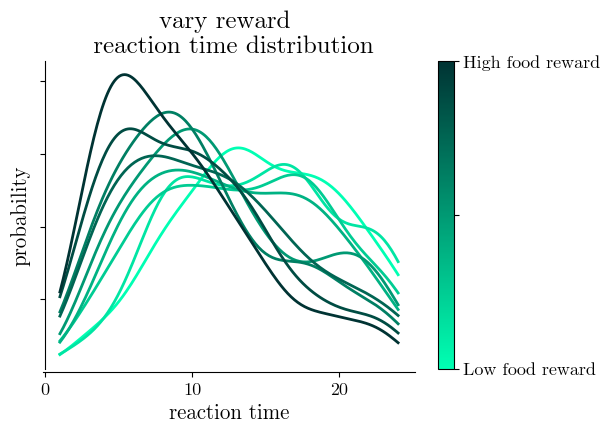

ycstore/seed_0_varyrewardemulatev2_epoch_14


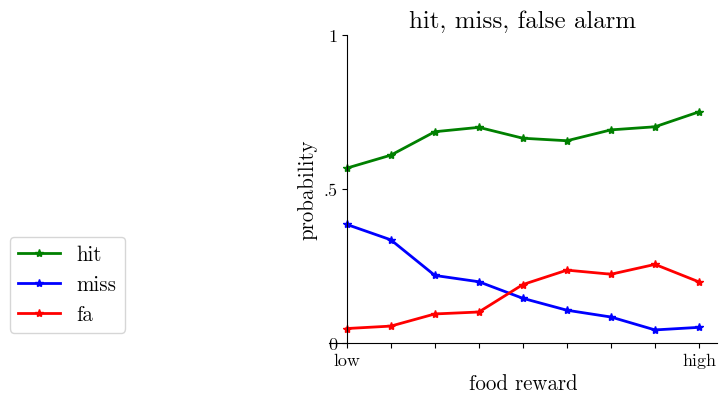

webf NOT subset; don't know how to subset; dropped


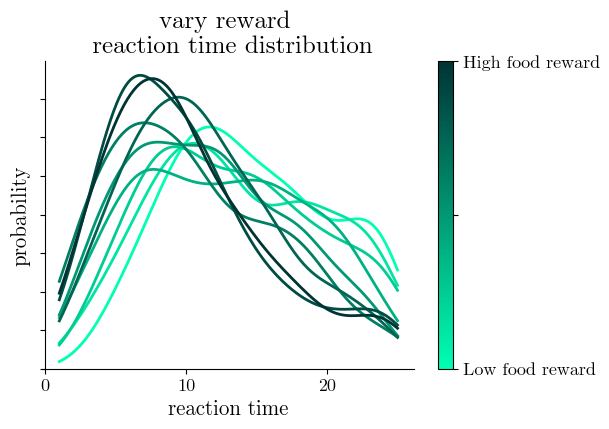

ycstore/seed_0_varyrewardemulatev2_epoch_15


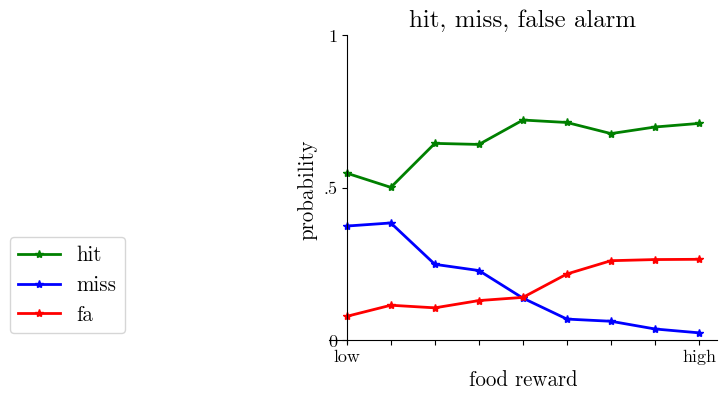

webf NOT subset; don't know how to subset; dropped


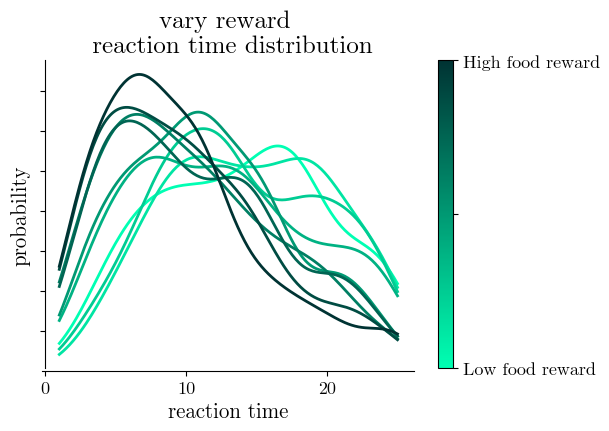

ycstore/seed_0_varyrewardemulatev2_epoch_16


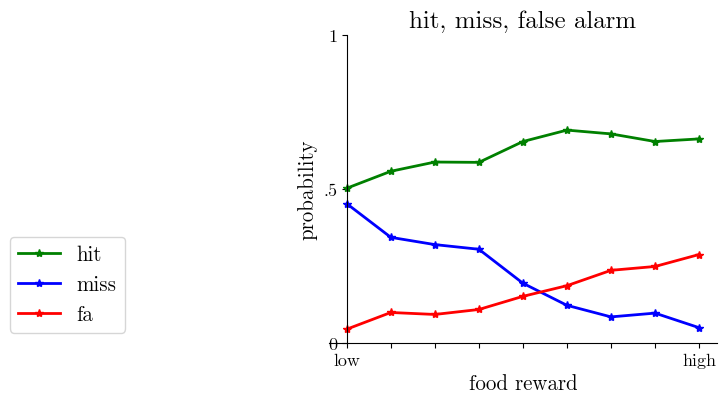

webf NOT subset; don't know how to subset; dropped


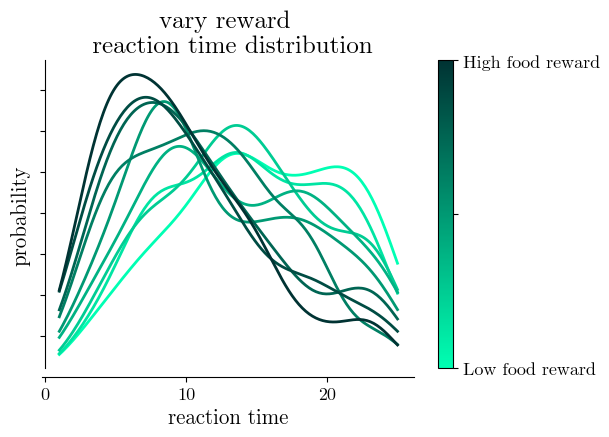

ycstore/seed_0_varyrewardemulatev2_epoch_17


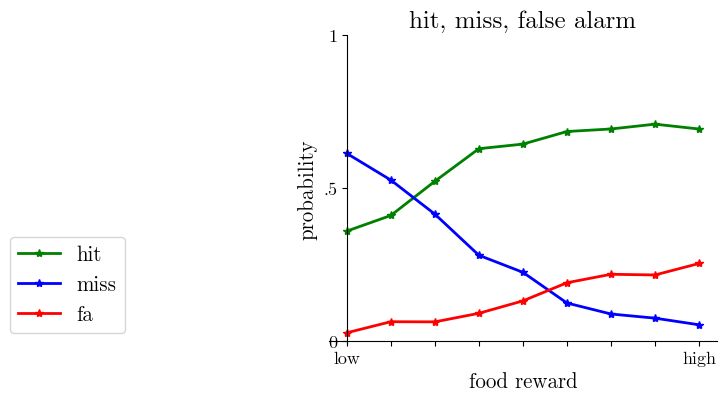

webf NOT subset; don't know how to subset; dropped


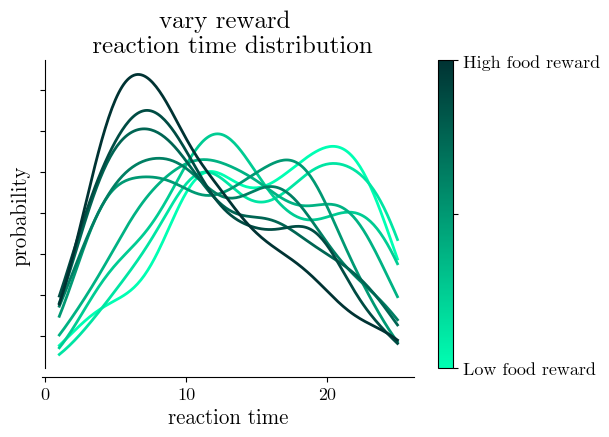

ycstore/seed_0_varyrewardemulatev2_epoch_18


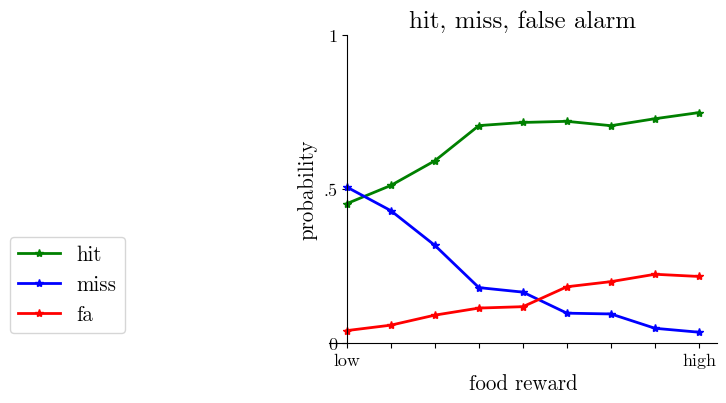

webf NOT subset; don't know how to subset; dropped


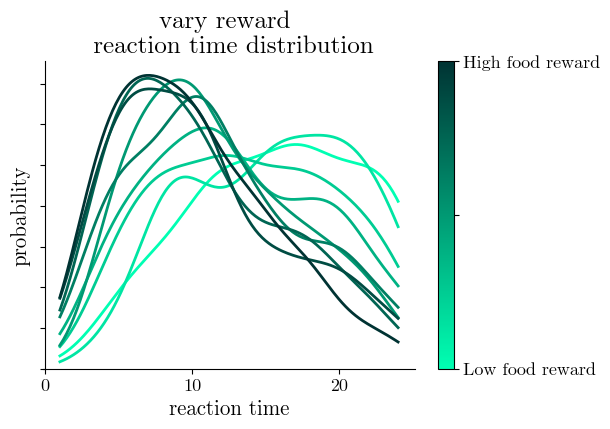

ycstore/seed_0_varyrewardemulatev2_epoch_19


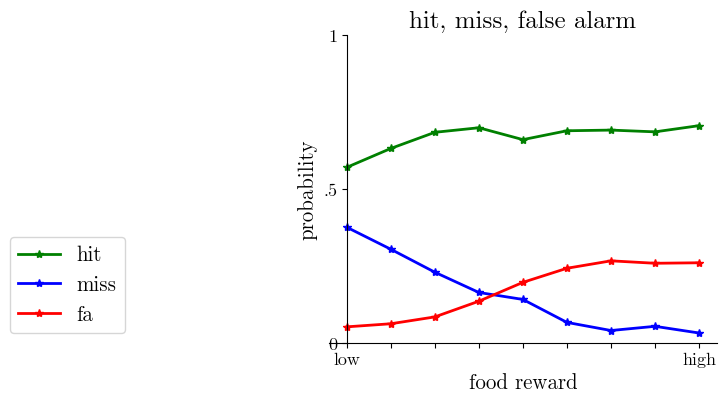

webf NOT subset; don't know how to subset; dropped


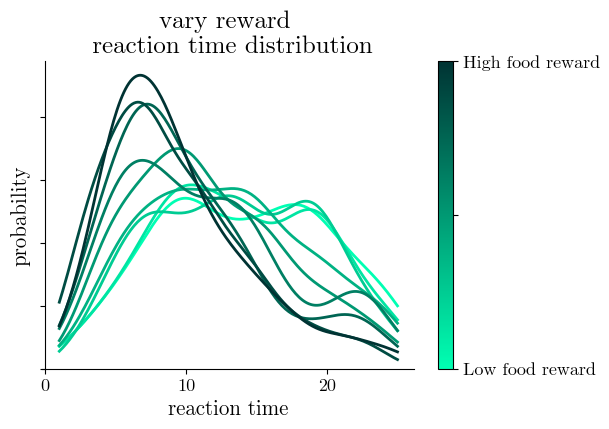

ycstore/seed_0_varyrewardemulatev2_epoch_20


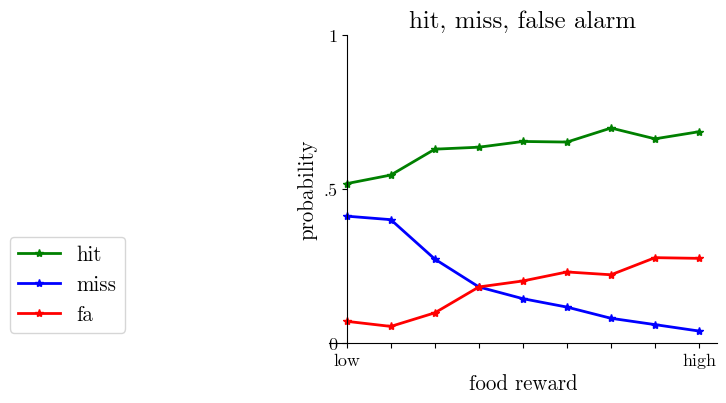

webf NOT subset; don't know how to subset; dropped


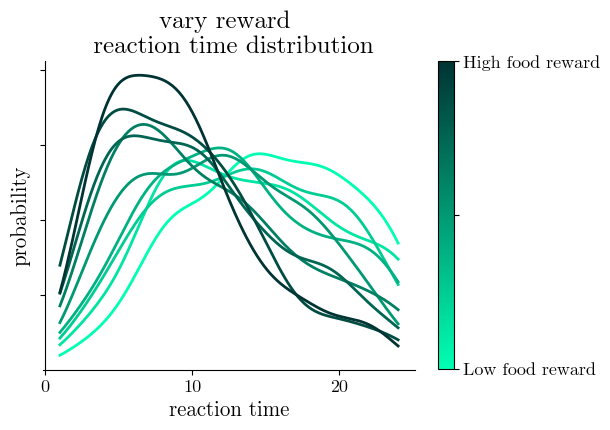

ycstore/seed_0_varyrewardemulatev2_epoch_21


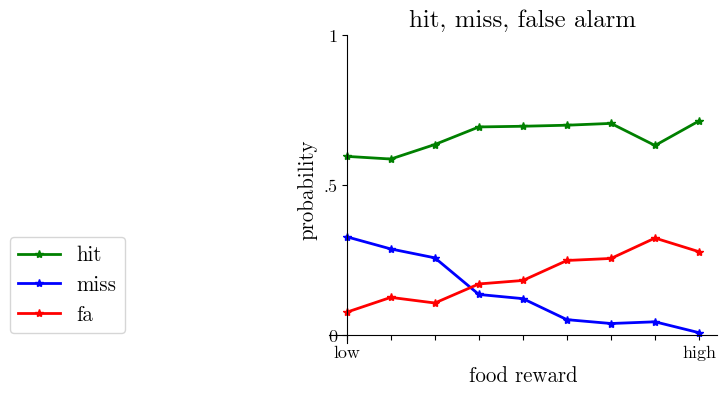

webf NOT subset; don't know how to subset; dropped


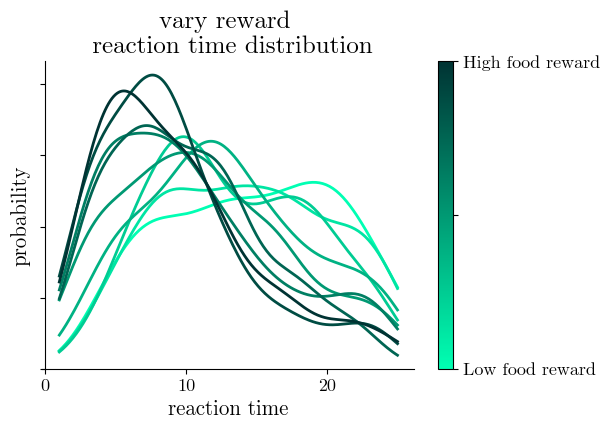

In [4]:
modelname = 'varyrewardemulatev2'
# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
attcost=-1.6
facost=-50
p1p2 = np.array([.6, .7])
vmin, vmax = 10, 5000
food_reward_list = np.linspace(vmin, vmax, 9)
print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])
env_param = [0, None, attcost, .25, facost, 0, 0]
seed=0
thismodel = f'seed_{seed}_{modelname}'

for seed in range(n_seed):
    # set seed
    np.random.seed(seed)
    task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                                'food_reward': env_param[1],
                                'attention_cost_coeff': env_param[2],
                                'attention_cost_temp': env_param[3],
                                'penalty_cost': env_param[4],
                                'iti_cost': env_param[5],
                                'time_in_game_reward': env_param[6]}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    # set p1 p2
    task.obs_certainity_possible = p1p2
    model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}",)
    # train
    for i in range(n_epoch):
        model.learn(total_timesteps=epoch_size,
                    tb_log_name=thismodel,
                    reset_num_timesteps=False,
                    )
        model.save(f'ycstore/{thismodel}_epoch_{i}')
        print(f'ycstore/{thismodel}_epoch_{i}')

        # eval
        # collect trial data
        no_episodes=3333
        def eval_wrapper(a):
            episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                    num_steps=100000, deterministic=True)
            return episode

        with multiprocess.Pool(processes=8) as pool:
            all_episode_data = pool.map(eval_wrapper, range(no_episodes))

        # process trial data
        def process_one_episode_wrapper(episode):
            return process_one_episode(episode, task)
        with multiprocess.Pool(processes=8) as pool:
            results = pool.map(process_one_episode_wrapper, all_episode_data)

        # process the mp results
        hit_count_list = [[0] for _ in range(len(food_reward_list))]
        miss_count_list = [[0] for _ in range(len(food_reward_list))]
        false_alarm_list = [[0] for _ in range(len(food_reward_list))]

        noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
        signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
        total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
        total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

        # dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
        total_reward_dist= [[] for _ in range(len(food_reward_list))]
        rt_hit_dist=[[] for _ in range(len(food_reward_list))]
        rt_fa_dist=[[] for _ in range(len(food_reward_list))]
        total_att_time_dist = [[] for _ in range(len(food_reward_list))]
        for res in results:
            (food_reward_idx,
            hit_count,
            miss_count,
            false_alarm_count,

            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,

            total_reward,

            attention_time_points_across_episodes,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes,
            fa_reaction_time_across_episodes
            ) = res

            hit_count_list[food_reward_idx][0] += (hit_count)
            miss_count_list[food_reward_idx][0] += (miss_count)
            false_alarm_list[food_reward_idx][0] += (false_alarm_count)

            noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
            signal_time_before_lick_list[food_reward_idx][0] += (
                signal_time_before_lick)
            total_noise_time_list[food_reward_idx][0] += (total_noise_time)
            total_signal_time_list[food_reward_idx][0] += (total_signal_time)

            total_reward_dist[food_reward_idx].append(total_reward)
            rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
            rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
            total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))


        # 3 curve
        hit_count_list, miss_count_list, false_alarm_list = np.array(
            hit_count_list), np.array(miss_count_list), np.array(false_alarm_list)
        hit_prob = [hit_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                        false_alarm_list[i]) for i in range(len(hit_count_list))]
        miss_prob = [miss_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                            false_alarm_list[i]) for i in range(len(hit_count_list))]
        fa_prob = [false_alarm_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                        false_alarm_list[i]) for i in range(len(hit_count_list))]

        xs=np.arange(len(food_reward_list))
        fig, ax=plt.subplots(1,1, figsize=(5,4))

        ax.plot(xs, hit_prob, '-*g', label='hit')
        ax.plot(xs, miss_prob, '-*b', label='miss')
        ax.plot(xs, fa_prob, '-*r', label='fa')
        quickleg(ax, bbox_to_anchor=(-0.5,0))
        ax.set_xlabel('food reward')
        ax.set_ylabel('probability')
        # ax.set_xticks(xs, [f'{a:.0f}' for a in food_reward_list]) # actual values
        ax.set_xticks([xs[i] for i in [0,-1]], ['low', 'high']) # low high
        ax.set_xticks(xs)
        ax.set_yticks([0,0.5,1], ['0', '.5','1'])
        ax.set_xticks(xs)
        centerax(ax)
        ax.set_title('hit, miss, false alarm')
        plt.show()

        # reaction time

        start_rgb = (0.0, 1, 0.7)
        end_rgb = (0.0, 0.2, 0.2)
        cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])


        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        data = []
        for food_reward_idx, v in enumerate(rt_hit_dist):
            v = np.array(v)
            v = v[v > 1]  # ignore the 0 reaction time in the plots
            if len(v) == 0:
                continue
            data.append((food_reward_idx, v))


        for i, (food_reward_idx, curve) in enumerate(data):
            sns.kdeplot(curve, label=f'reward:{food_reward_list[food_reward_idx]:.0f}', clip=(1, np.max(v)), bw_adjust=1,color=cmap(np.linspace(0, 1, len(data)))[i])

            # plt.plot(curve, color=cmap(np.linspace(0, 1, len(data)))[i])
        color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
        ticks = [0, 0.5, 1]
        tick_labels = ['Low food reward', '', 'High food reward']
        color_bar.set_ticks(ticks)
        color_bar.set_ticklabels(tick_labels)

        ax.set_ylabel('probability')
        ax.set_xlabel('reaction time')
        centerax(ax)
        ax.set_xticks([0, 10, 20])
        ax.set_yticklabels([])
        # quickleg(ax, bbox_to_anchor=(-0.5, 0))
        ax.set_title('vary reward \n reaction time distribution')
        quicksave('reaction time distribution v3 full', modelname)
        plt.show()

    notify(f'training {thismodel} finished')
modeli += 1